In [1]:
from pathlib import Path
from IPython.display import Image, display
from PIL import Image
import math

import pandas as pd
import matplotlib.pyplot as plt
import os

# Etape 1 : Importer et explorer les données

In [2]:
DATA_ROOT = Path("data") / "mri_dataset_brain_cancer_oc"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

records = []

def add_record(image_path, subset_name, label=None):
    records.append(
        {
            "filepath": str(image_path.resolve()),
            "filename": image_path.name,
            "source_path": str(image_path.parent.resolve()),
            "label": label,
            "subset": subset_name,
        }
    )

# Sous-ensemble fortement labellisé: attendu en arborescence avec_labels/<label>/image
labeled_root = DATA_ROOT / "avec_labels"
for label_dir in labeled_root.iterdir():
    if not label_dir.is_dir():
        continue

    label_name = label_dir.name
    for image_path in label_dir.rglob("*"):
        if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
            add_record(image_path, subset_name="avec_labels", label=label_name)

# Sous-ensemble faiblement labellisé: images directement dans sans_label
unlabeled_root = DATA_ROOT / "sans_label"
for image_path in unlabeled_root.rglob("*"):
    if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
        add_record(image_path, subset_name="sans_label", label=None)

df = pd.DataFrame(records)
df.head()
df.describe(include="all")

df[['subset']]


,subset
0,avec_labels
1,avec_labels
2,avec_labels
3,avec_labels
4,avec_labels
...,...
1501,sans_label
1502,sans_label
1503,sans_label
1504,sans_label


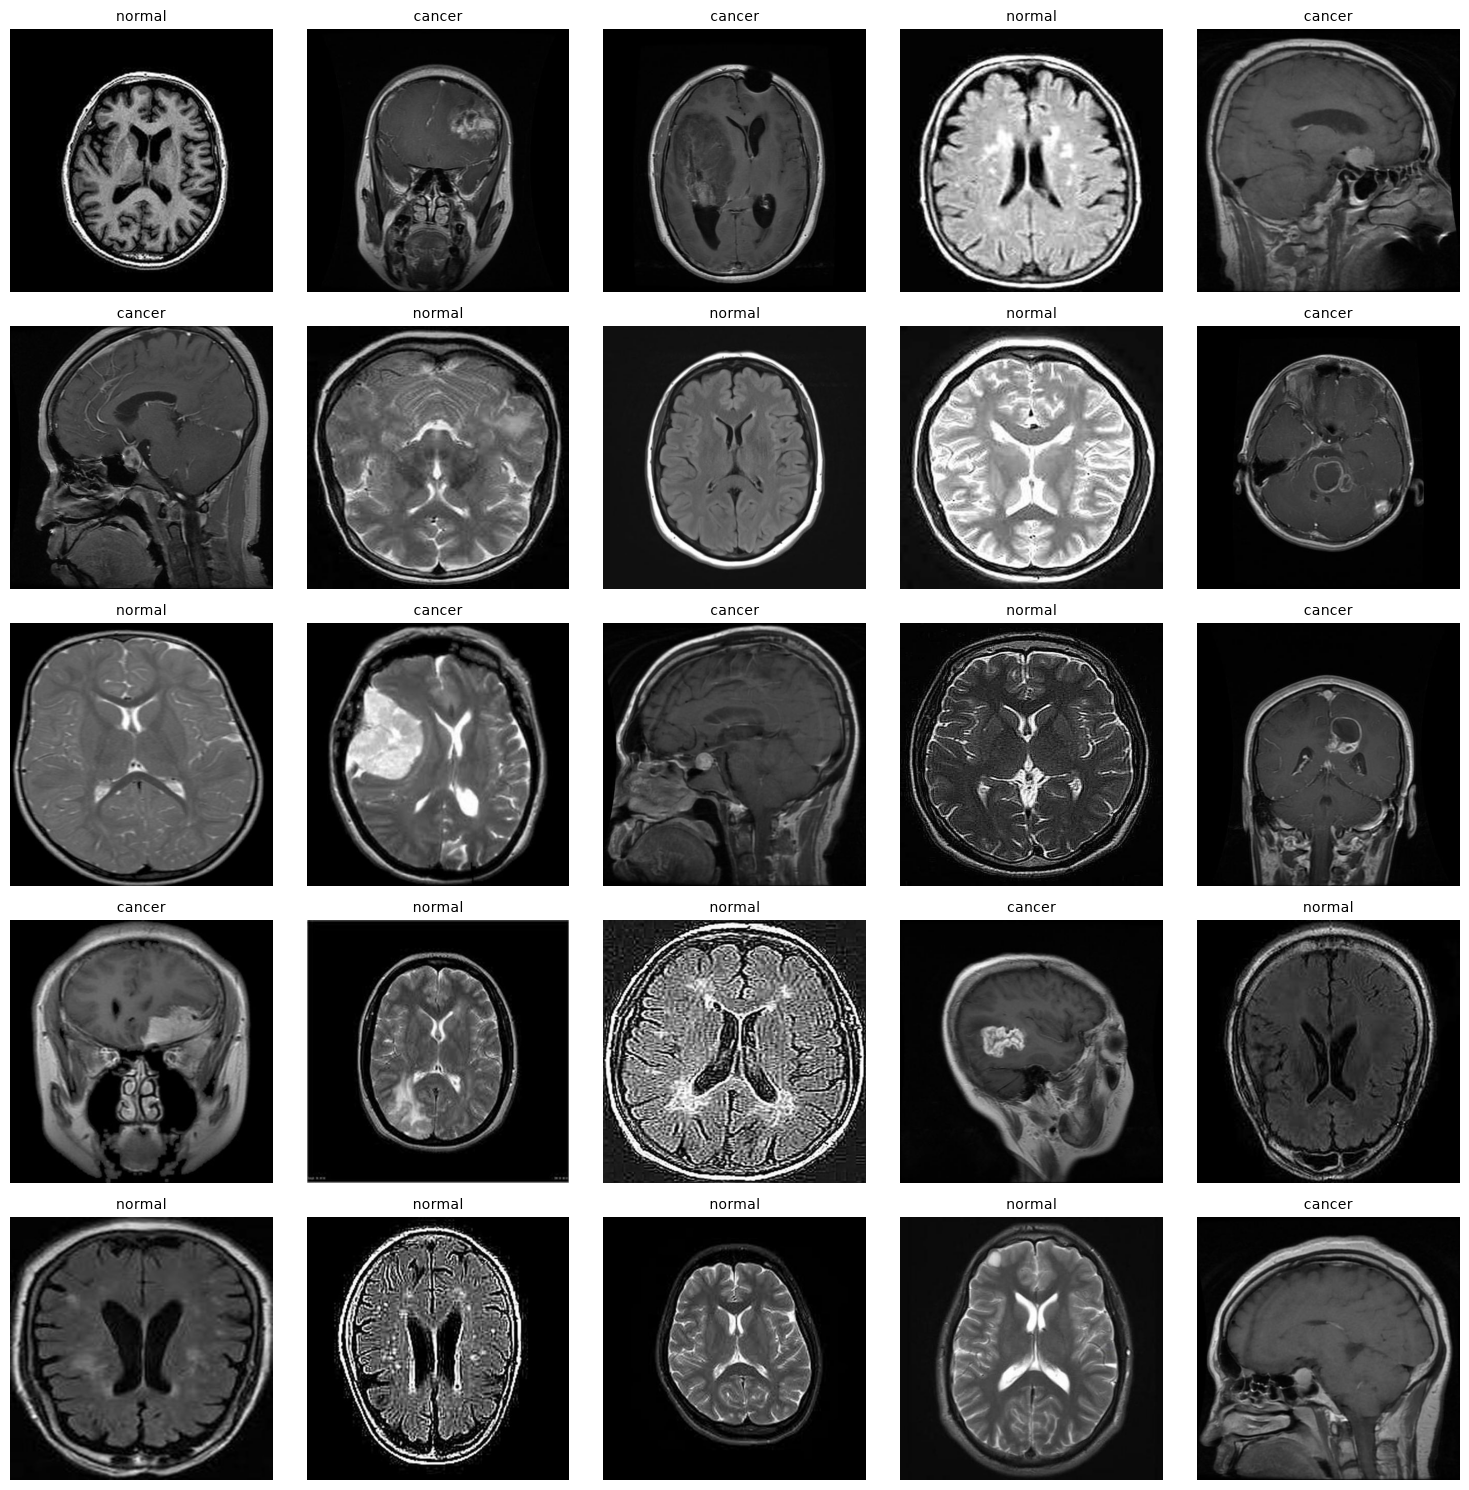

In [3]:
# 1. Configuration de la grille (5 lignes, 5 colonnes = 25 images)
n_rows = 5
n_cols = 5
num_examples = n_rows * n_cols

# 2. Filtrage et sélection aléatoire
df_filtered = df[df['subset'] == 'avec_labels']
num_examples = min(num_examples, len(df_filtered))
df_random = df_filtered.sample(n=num_examples)

# Recalculer le nombre de lignes nécessaire si le dataset est trop petit
n_rows = math.ceil(num_examples / n_cols)

# 3. Création de la figure (ajustement de la taille de la figure en hauteur)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))

# Forcer 'axes' à être une liste à 1 dimension pour pouvoir boucler facilement dessus
axes = axes.flatten()

# 4. Boucle d'affichage
for i in range(num_examples):
    try:
        img_path = df_random.iloc[i]['filepath']
        label = df_random.iloc[i]['label']
        
        image = Image.open(img_path)
        axes[i].imshow(image)
        axes[i].set_title(label, fontsize=10)
        axes[i].axis("off")

    except Exception as e:
        print(f"Erreur à l'index {i} ({img_path}): {e}")
        axes[i].axis("off")

# 5. Masquer les cases vides si le dataset avait moins d'images que prévu
for j in range(num_examples, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [4]:
corrupted_files = []
valid_metadata = []

print("--- VÉRIFICATION DE L'INTÉGRITÉ DES IMAGES ---")

# On parcourt le dataset pour tester l'ouverture des fichiers
for idx, row in df.iterrows():
    path = row['filepath']
    try:
        with Image.open(path) as img:
            img.verify() # Vérifie l'intégrité sans charger toute l'image en mémoire
        
        # Si valide, on recharge proprement pour extraire les dimensions et canaux
        with Image.open(path) as img:
            valid_metadata.append({
                'index': idx,
                'width': img.width,
                'height': img.height,
                'mode': img.mode, # RGB, RGBA, L (niveaux de gris)
                'format_physique': img.format # JPEG, PNG, etc.
            })
    except Exception as e:
        corrupted_files.append((path, str(e)))

print(f"Nombre d'images corrompues/introuvables : {len(corrupted_files)}")
if corrupted_files:
    print("Exemples de fichiers problématiques :")
    for p, err in corrupted_files[:5]:
        print(f"- {p} -> Erreur : {err}")


--- VÉRIFICATION DE L'INTÉGRITÉ DES IMAGES ---
Nombre d'images corrompues/introuvables : 0


## Analyse des dimensions et résolutions

In [5]:
if valid_metadata:
    df_meta = pd.DataFrame(valid_metadata)
    
    print("\n--- ANALYSE DES DIMENSIONS ET RÉSOLUTIONS ---")
    # Statistiques sur la largeur et la hauteur
    print(df_meta[['width', 'height']].describe())
    
    # Résolution (Ratio Largeur/Hauteur) pour détecter les images étirées
    df_meta['aspect_ratio'] = df_meta['width'] / df_meta['height']
    print("\nStatistiques du Ratio d'aspect (Width/Height) :")
    print(df_meta['aspect_ratio'].describe())
    
    print("\n--- ANALYSE DES CANAUX ET FORMATS REELS ---")
    # Modes de couleur : RGB (3 canaux), RGBA (4 canaux), L (1 canal / Noir et blanc)
    print("Modes de couleurs réels des images :")
    print(df_meta['mode'].value_counts())
    
    print("\nFormats d'encodage réels des images :")
    print(df_meta['format_physique'].value_counts())
else:
    print("Aucune image valide analysée.")


--- ANALYSE DES DIMENSIONS ET RÉSOLUTIONS ---
        width  height
count  1506.0  1506.0
mean    512.0   512.0
std       0.0     0.0
min     512.0   512.0
25%     512.0   512.0
50%     512.0   512.0
75%     512.0   512.0
max     512.0   512.0

Statistiques du Ratio d'aspect (Width/Height) :
count    1506.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: aspect_ratio, dtype: float64

--- ANALYSE DES CANAUX ET FORMATS REELS ---
Modes de couleurs réels des images :
mode
RGB    1506
Name: count, dtype: int64

Formats d'encodage réels des images :
format_physique
JPEG    1506
Name: count, dtype: int64


L'ensemble du jeu de données est bien redimensionnées en 512×512 pixels.

# Etape 2 : Extraire des embeddings visuels

In [6]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import numpy as np
import pandas as pd
from tqdm import tqdm

## Configuration et Préparation des Données

In [14]:
# Sélection du processeur (GPU si disponible, sinon CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du périphérique : {device}")

# IMPORTANT: pour le semi-supervisé, on garde tout le dataset
# (avec_labels + sans_label) afin d'extraire des embeddings pour les 2 subsets.
df_work = df.reset_index(drop=True)

# Définition des transformations standards pour ResNet (ImageNet)
transform_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),               # Taille requise par ResNet
    transforms.ToTensor(),                       # Conversion en tenseur PyTorch [0, 1]
    transforms.Normalize(                        # Normalisation ImageNet (Moyenne & Écart-type)
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

# Création d'un Dataset PyTorch personnalisé pour lire les images efficacement
class ImageEmbeddingDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform

        # Compatibilité avec les API qui attendent `dataset.labels` et `info['label']`
        if 'label' in self.df.columns:
            known_labels = sorted(self.df['label'].dropna().astype(str).unique().tolist())
            self.label_to_idx = {label_name: i for i, label_name in enumerate(known_labels)}
            self.labels = np.array(
                [self.label_to_idx.get(str(v), -1) if pd.notna(v) else -1 for v in self.df['label']],
                dtype=np.int64
            )
            self.info = {'label': {str(i): label_name for label_name, i in self.label_to_idx.items()}}
        else:
            self.label_to_idx = {}
            self.labels = np.full(len(self.df), -1, dtype=np.int64)
            self.info = {'label': {}}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['filepath']
        try:
            # Ouverture et conversion forcée en RGB (3 canaux)
            with Image.open(img_path) as img:
                img = img.convert('RGB')
                return self.transform(img), idx, True
        except Exception:
            # En cas d'erreur sur l'image, on retourne un tenseur vide
            return torch.zeros(3, 224, 224), idx, False

    # def __getitem__(self, idx):
    #     row = self.df.iloc[idx]
    #     img_path = row['filepath']
    #     label = row.get('label_code', None)

    #     with Image.open(img_path) as img:
    #         img = img.convert('RGB')
    #         img = self.transform(img)

    #     if pd.isna(label):
    #         label = -1

    #     return img, int(label)

# Initialisation du DataLoader pour charger les images par lots (Batchs)
dataset = ImageEmbeddingDataset(df_work, transform=transform_pipeline)

# Creation des jeux de données
# 1) Jeu labellisé seulement
df_labeled = df_work[df_work['subset'] == 'avec_labels'].copy().reset_index(drop=True)
# 2)Jeu de données sans label
df_unlabeled = df_work[df_work['subset'] == 'sans_label'].copy()

# 3) Encodage des labels
label_to_idx = {label: i for i, label in enumerate(sorted(df_labeled['label'].unique()))}
df_labeled['label_code'] = df_labeled['label'].map(label_to_idx)

# 4) Split train/test sur le jeu labellisé
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_labeled,
    test_size=0.2,
    stratify=df_labeled['label'],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_dataset = ImageEmbeddingDataset(train_df, transform=transform_pipeline)
test_dataset = ImageEmbeddingDataset(test_df, transform=transform_pipeline)
# unlabeled_dataset = ImageEmbeddingDataset(df_unlabeled, transform=transform_pipeline)

# train_dataset = ImageEmbeddingDataset(
#     df_work[df_work['subset'] == 'avec_labels'],
#     transform=transform_pipeline
# )

# test_dataset = ImageEmbeddingDataset(
#     df_work[df_work['subset'] == 'sans_label'],
#     transform=transform_pipeline
# )
info = train_dataset.info
dataloader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)

Utilisation du périphérique : cpu


In [11]:
print(len(dataset))
print(len(train_dataset))
print(len(test_df))

1506
80
20


## Chargement du Modèle et Configuration

In [12]:
# Charger un modèle ResNet50 pré-entraîné
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# RECOMMANDATION : Geler toutes les couches convolutionnelles
for param in model.parameters():
    param.requires_grad = False

# RECOMMANDATION : Évaluer une autre couche d'extraction
# Au lieu de prendre la classification finale, on extrait la couche juste avant (Identity)
# Cela nous donne un vecteur de caractéristiques de taille 2048
model.fc = torch.nn.Identity()

# Basculer le modèle en mode évaluation et l'envoyer sur le GPU/CPU
model.eval()
model = model.to(device)

## Boucle d'Extraction des Embeddings

In [15]:
all_embeddings = []
valid_indices = []

print("Extraction des features en cours...")
with torch.no_grad(): # Désactive le calcul des gradients pour économiser la mémoire
    for imgs, idxs, status in tqdm(dataloader):
        # Filtrer uniquement les images qui ont réussi à charger
        valid_mask = status == True
        if not valid_mask.any():
            continue
            
        imgs = imgs[valid_mask].to(device)
        idxs = idxs[valid_mask]
        
        # Passage dans le modèle pour obtenir les features
        features = model(imgs)
        
        # Stockage sous forme de tableau NumPy
        all_embeddings.append(features.cpu().numpy())
        valid_indices.extend(idxs.tolist())

# Fusion de tous les batchs en une seule matrice NumPy
features_matrix = np.vstack(all_embeddings)
print(f"Forme de la matrice finale : {features_matrix.shape}") 
# Résultat attendu : (Nombre d'images valides, 2048)

Extraction des features en cours...


100%|██████████| 48/48 [00:59<00:00,  1.24s/it]

Forme de la matrice finale : (1506, 2048)


## Sauvegarde dans un Tableau Exploitable

In [16]:
# Option A : Sauvegarde brute au format NumPy
np.save('images_embeddings.npy', features_matrix)

# Option B : Liaison avec le DataFrame Pandas d'origine
df_features = df_work.iloc[valid_indices].copy()
# Créer une liste de vecteurs dans une seule colonne Pandas
df_features['embedding'] = list(features_matrix)
df_features.to_pickle('df_with_embeddings.pkl') # Sauvegarde au format pickle pour conserver les listes

print("Sauvegarde effectuée avec succès !")

Sauvegarde effectuée avec succès !


# Etape 3 : Analyse non supervisé

## ALIGNEMENT ET SÉPARATION DES DONNÉES (FORT VS FAIBLE)

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, roc_auc_score, accuracy_score, f1_score

# /!\ IMPORTANT : Utilisez le 'df_features' (ou les indices valides) de l'étape précédente
# pour garantir que la matrice d'embeddings et les lignes du DataFrame sont parfaitement alignées.
# Ici, nous supposons que 'df_work' contient uniquement les lignes valides et 'features_matrix' leurs embeddings.

# Filtre pour le jeu fortement labellisé
mask_fort = df_features['subset'] == 'avec_labels'
df_fort = df_features[mask_fort].copy().reset_index(drop=True)
X_fort = features_matrix[mask_fort]
y_true_fort = df_fort['label'].astype('category').cat.codes.values # Encodage 0/1 pour l'ARI

# Filtre pour le jeu faiblement labellisé (sans labels d'origine)
mask_faible = df_features['subset'] == 'sans_label'
df_faible = df_features[mask_faible].copy().reset_index(drop=True)
X_faible = features_matrix[mask_faible]

df_features.describe()

,filepath,filename,source_path,label,subset,embedding
count,1506,1506,1506,100,1506,1506
unique,1506,1506,3,2,2,1506
top,C:\Formation\Projet_10\data\mri_dataset_brain_...,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,C:\Formation\Projet_10\data\mri_dataset_brain_...,cancer,sans_label,"[0.011641124, 0.01485502, 0.30946934, 0.112983..."
freq,1,1,1406,50,1406,1


## STANDARDISATION ET RÉDUCTION DE DIMENSION (PCA)

In [42]:
# Recommandation : Standardisation
scaler = StandardScaler()
X_fort_scaled = scaler.fit_transform(X_fort)
if len(X_faible) > 0 :
    X_faible_scaled = scaler.transform(X_faible)

# PCA pour la visualisation 2D
pca = PCA(n_components=2, random_state=42)
X_fort_pca = pca.fit_transform(X_fort_scaled)
if len(X_faible) > 0 :
    X_faible_pca = pca.transform(X_faible_scaled)

## COMPARAISON DE DEUX MÉTHODES DE CLUSTERING (SUR LE JEU FORT)

In [43]:
# Méthode 1 : K-Means (Contrainte : 2 clusters)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_fort_kmeans = kmeans.fit_predict(X_fort_scaled)
ari_kmeans = adjusted_rand_score(y_true_fort, clusters_fort_kmeans)

# Méthode 2 : Clustering Hiérarchique (Contrainte : 2 clusters, alternative à DBSCAN)
# Justification : DBSCAN trouve un nombre de clusters variable et génère du bruit (-1).
# L'agglomerative clustering est parfait pour tester une autre métrique de distance.
hc = AgglomerativeClustering(n_clusters=2, linkage='ward')
clusters_fort_hc = hc.fit_predict(X_fort_scaled)
ari_hc = adjusted_rand_score(y_true_fort, clusters_fort_hc)

print("--- ÉVALUATION DES MÉTHODES (JEU FORT) ---")
print(f"Score ARI avec K-Means : {ari_kmeans:.4f}")
print(f"Score ARI avec Clustering Hiérarchique : {ari_hc:.4f}\n")

--- ÉVALUATION DES MÉTHODES (JEU FORT) ---
Score ARI avec K-Means : 0.2854
Score ARI avec Clustering Hiérarchique : 0.7721



## APPLICATION DE LA MEILLEURE MÉTHODE SUR LE JEU FAIBLE

In [44]:
# Vérification avant clustering faible
if len(X_faible) == 0:
    print("Aucune donnée dans le jeu faible : pas de labellisation faible.")
    df_faible['weak_label'] = pd.Series(dtype='int64')
else:
    # Standardisation (si pas déjà fait dans la cellule précédente)
    X_faible_scaled = scaler.transform(X_faible)

    # On sélectionne le modèle qui a obtenu le meilleur score ARI
    if ari_kmeans >= ari_hc:
        print("-> K-Means sélectionné pour la labellisation faible.")
        clusters_faible = kmeans.predict(X_faible_scaled)
    else:
        print("-> Clustering Hiérarchique sélectionné pour la labellisation faible.")
        clusters_faible = hc.fit_predict(X_faible_scaled)

    df_faible['weak_label'] = clusters_faible

-> Clustering Hiérarchique sélectionné pour la labellisation faible.


## VISUALISATION DES RÉSULTATS (GRAPHES 2D)

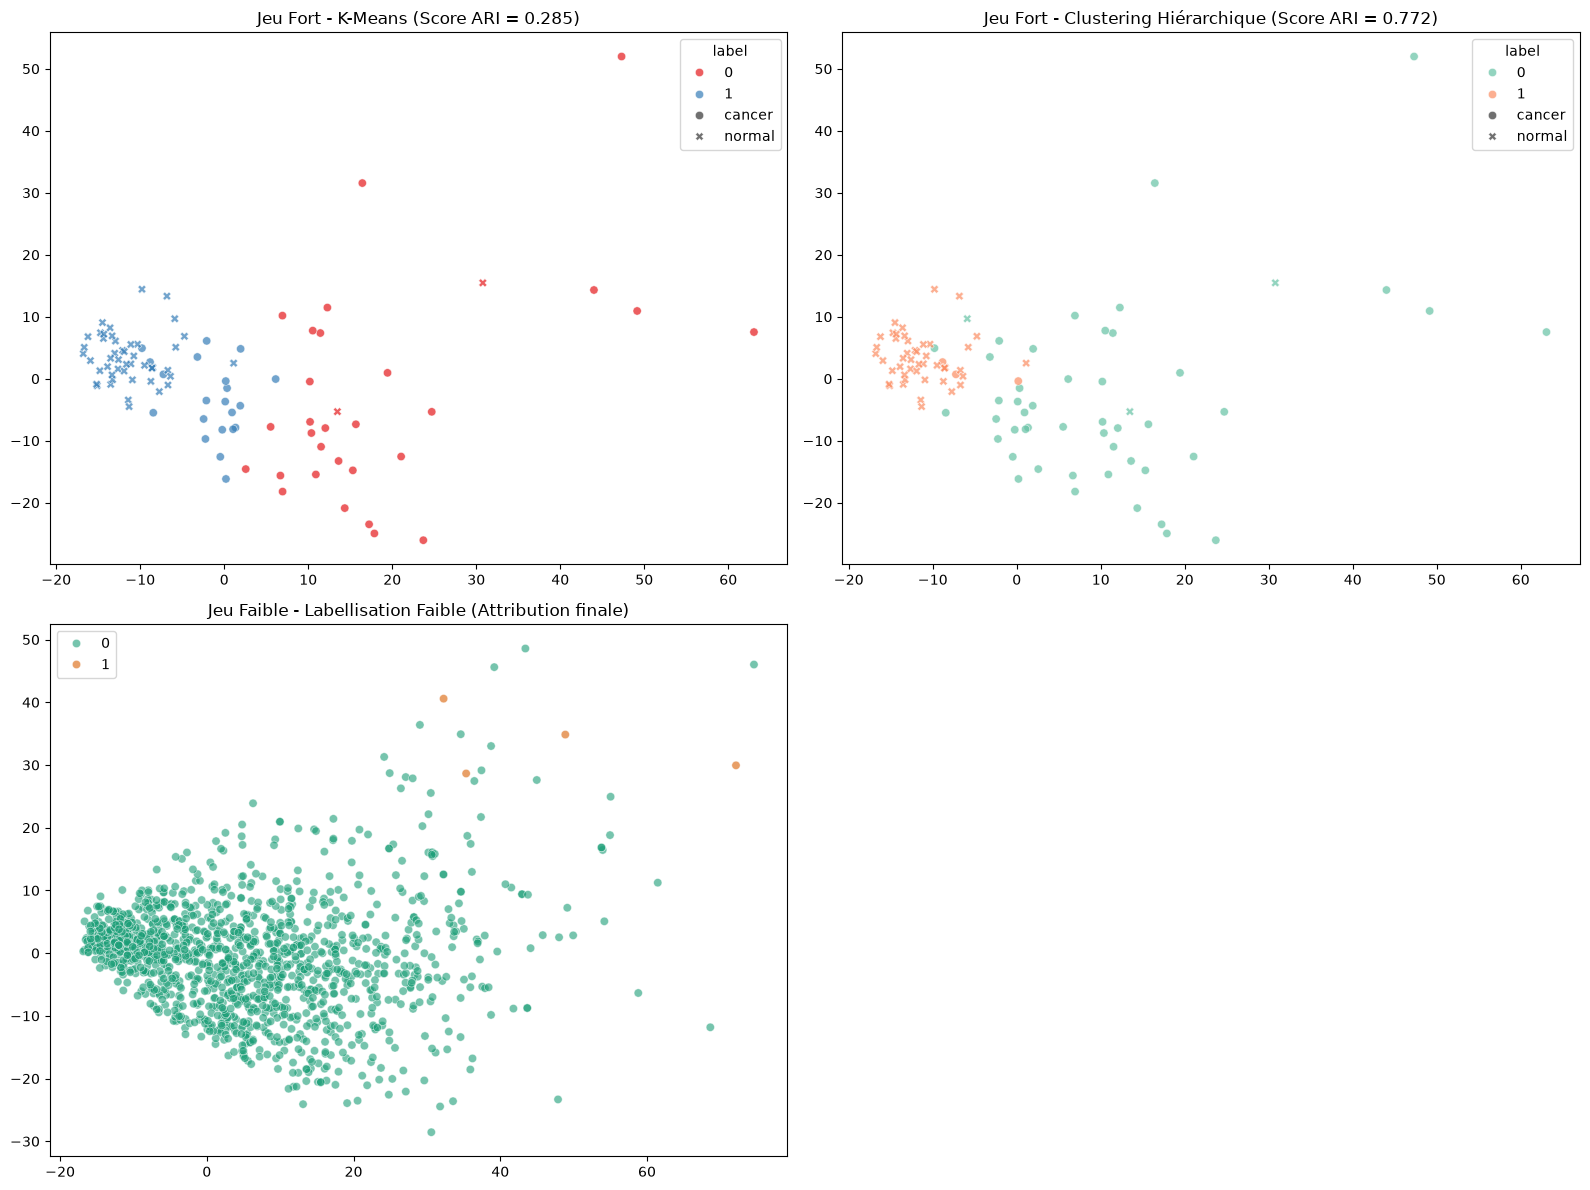

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- LIGNE 1 : ANALYSE ET COMPARATIF SUR LE JEU FORT ---
# Graphe 1 : K-Means
sns.scatterplot(x=X_fort_pca[:, 0], y=X_fort_pca[:, 1], hue=clusters_fort_kmeans, style=df_fort['label'], palette='Set1', alpha=0.7, ax=axes[0,0])
axes[0,0].set_title(f"Jeu Fort - K-Means (Score ARI = {ari_kmeans:.3f})")

# Graphe 2 : Clustering Hiérarchique
sns.scatterplot(x=X_fort_pca[:, 0], y=X_fort_pca[:, 1], hue=clusters_fort_hc, style=df_fort['label'], palette='Set2', alpha=0.7, ax=axes[0,1])
axes[0,1].set_title(f"Jeu Fort - Clustering Hiérarchique (Score ARI = {ari_hc:.3f})")

# --- LIGNE 2 : APPLICATION SUR LE JEU FAIBLE (SÉPARÉ) ---
if len(X_faible) > 0 and 'clusters_faible' in locals():
    sns.scatterplot(
        x=X_faible_pca[:, 0],
        y=X_faible_pca[:, 1],
        hue=clusters_faible,
        palette='Dark2',
        alpha=0.6,
        ax=axes[1,0]
    )
    axes[1,0].set_title("Jeu Faible - Labellisation Faible (Attribution finale)")
else:
    axes[1,0].axis('off')
    axes[1,0].text(0.5, 0.5, "Aucune donnée dans le jeu faible", ha='center', va='center')
# Désactivation de la quatrième case vide pour garder un rendu propre
axes[1,1].axis('off')

plt.tight_layout()
plt.show()


## Etape 4 : Entraînement CNN — Comparaison Supervisé vs Semi-Supervisé

In [23]:
# On prend tout le set d'entraînement initial
all_indices = list(range(len(dataset)))

labeled_indices = dataset.df.index[dataset.df['subset'] == 'avec_labels'].tolist()
unlabeled_indices = dataset.df.index[dataset.df['subset'] == 'sans_label'].tolist()

# Les indices non étiquetés sont le reste
unlabeled_indices = list(set(all_indices) - set(labeled_indices))

# Création des Subsets PyTorch
labeled_dataset = Subset(dataset, labeled_indices)
unlabeled_dataset = Subset(dataset, unlabeled_indices)

print(f"Taille du jeu de données étiqueté : {len(labeled_dataset)}")
print(f"Taille du jeu de données non-étiqueté : {len(unlabeled_dataset)}")
print(f"Taille du jeu de test : {len(test_dataset)}")

# DataLoaders
labeled_loader = DataLoader(dataset=labeled_dataset, batch_size=16, shuffle=True)
unlabeled_loader = DataLoader(dataset=unlabeled_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=128, shuffle=False)

Taille du jeu de données étiqueté : 100
Taille du jeu de données non-étiqueté : 1406
Taille du jeu de test : 20


Distribution des classes dans le 'labeled_dataset' (100 images) :

Classe 0 (cancer): 50 images
Classe 1 (normal): 50 images


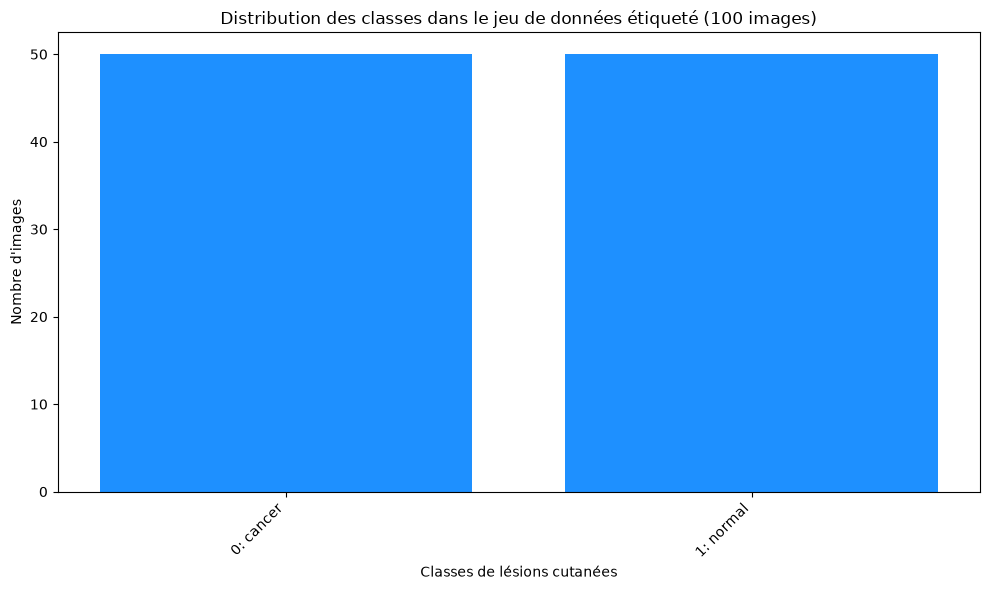

In [26]:
# Les labels du dataset complet sont dans train_dataset.labels
# On récupère les labels correspondant aux indices de notre jeu étiqueté
labels_of_labeled_set = dataset.labels[labeled_indices]

# Compter le nombre d'occurrences de chaque classe
class_counts = np.bincount(np.array(labels_of_labeled_set).flatten(), minlength=2)
class_names = [f'{i}: {name}' for i, name in info['label'].items()]

# Afficher les comptes
print("Distribution des classes dans le 'labeled_dataset' (100 images) :\n")
for i, count in enumerate(class_counts):
    # Récupérer le nom complet de la classe
    full_class_name = info['label'][str(i)]
    print(f"Classe {i} ({full_class_name}): {count} images")

# Créer un graphique à barres pour visualiser la distribution
plt.figure(figsize=(10, 6))
plt.bar(class_names, class_counts, color='dodgerblue')
plt.xlabel('Classes de lésions cutanées')
plt.ylabel("Nombre d'images")
plt.title("Distribution des classes dans le jeu de données étiqueté (100 images)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Le modèle de base (supervisé)

In [27]:
# Définition d'un petit CNN (vous pouvez l'améliorer !)
class SimpleCNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(SimpleCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc = nn.Linear(56 * 56 * 32, num_classes) # 56*56*32 = 100352

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        return out

# Définir le device (à mettre au début de votre code si ce n'est pas déjà fait)
device = torch.device("cpu")

# On instancie la loss (sans poids car dataset équilibré)
criterion = nn.CrossEntropyLoss()

# On déplace aussi le modèle sur le device
model = SimpleCNN(in_channels=3, num_classes=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

#### Initialisation des métriques


In [28]:
# Listes globales pour tracer les métriques au fil des étapes
metrics_auc, metrics_acc, metrics_f1 = [], [], []


def plot_metrics():
    """Trace l'évolution des AUC/Accuracy/F1 macro si des valeurs sont disponibles."""
    if len(metrics_auc) == 0:
        print("Aucune métrique enregistrée pour le moment.")
        return
    steps = range(1, len(metrics_auc) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(steps, metrics_auc, label='AUC')
    plt.plot(steps, metrics_acc, label='Accuracy')
    plt.plot(steps, metrics_f1, label='F1 (macro)')
    plt.xlabel('Étape / Itération')
    plt.ylabel('Score')
    plt.title("Évolution des métriques")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [29]:
def train_and_evaluate(model, train_loader, test_loader, optimizer, criterion, epochs=10):
    """
    Entraîne et évalue un modèle. Retourne (AUC, ACC, F1).
    Compatible avec deux formats de batch:
      - (images, labels)
      - (images, idx, status) quand le Dataset renvoie aussi l'index et l'état de lecture.
    """
    device = next(model.parameters()).device

    def labels_from_indices(loader, idx_tensor):
        ds = loader.dataset
        base_ds = ds.dataset if hasattr(ds, 'dataset') else ds
        if not hasattr(base_ds, 'labels'):
            raise ValueError("Le dataset ne contient pas l'attribut 'labels'.")
        labels_np = base_ds.labels[idx_tensor.cpu().numpy()]
        return torch.from_numpy(labels_np).long()

    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            if len(batch) == 3:
                images, idx, status = batch
                valid_mask = status.bool()
                if valid_mask.sum().item() == 0:
                    continue
                images = images[valid_mask]
                idx = idx[valid_mask]
                labels = labels_from_indices(train_loader, idx)
            else:
                images, labels = batch
                labels = labels.squeeze().long()

            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Évaluation
    model.eval()
    y_true = torch.tensor([], dtype=torch.long, device=device)
    y_score_logits = torch.empty((0, 2), device=device)
    y_score_preds = torch.tensor([], dtype=torch.long, device=device)
    with torch.no_grad():
        for batch in test_loader:
            if len(batch) == 3:
                images, idx, status = batch
                valid_mask = status.bool()
                if valid_mask.sum().item() == 0:
                    continue
                images = images[valid_mask]
                idx = idx[valid_mask]
                labels = labels_from_indices(test_loader, idx)
            else:
                images, labels = batch
                labels = labels.squeeze().long()

            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            y_true = torch.cat((y_true, labels), 0)
            y_score_logits = torch.cat((y_score_logits, outputs), 0)
            y_score_preds = torch.cat((y_score_preds, preds), 0)

    y_true = y_true.cpu().numpy()
    y_score_logits = y_score_logits.detach().cpu().numpy()
    y_score_preds = y_score_preds.detach().cpu().numpy()

    print("y_true shape:", y_true.shape, "dtype:", y_true.dtype)
    print("unique y_true:", np.unique(y_true))
    print("y_score_logits shape:", y_score_logits.shape)
    print("y_score_preds shape:", y_score_preds.shape)

    if y_true.size == 0:
        auc = float("nan")
        acc = float("nan")
        f1 = float("nan")
    else:
        y_true = y_true.astype(np.int64)

        if y_score_logits.ndim == 2 and y_score_logits.shape[1] > 1:
            logits_for_auc = y_score_logits[:, 1]
        else:
            logits_for_auc = y_score_logits.ravel()

        if len(np.unique(y_true)) == 2:
            auc = roc_auc_score(y_true, logits_for_auc)
        else:
            auc = roc_auc_score(y_true, y_score_logits, multi_class='ovr', average='macro')

        acc = accuracy_score(y_true, y_score_preds)
        f1 = f1_score(y_true, y_score_preds, average='macro')

    try:
        metrics_auc.append(auc)
        metrics_acc.append(acc)
        metrics_f1.append(f1)
    except NameError:
        pass

    print(f'AUC: {auc:.3f}, Accuracy: {acc:.3f}, F1: {f1:.3f}')
    return (auc, acc, f1)

print("Entraînement du modèle de base sur 100 images labellisées...")
baseline_metrics = train_and_evaluate(model, labeled_loader, test_loader, optimizer, criterion)

Entraînement du modèle de base sur 100 images labellisées...
y_true shape: (20,) dtype: int64
unique y_true: [0 1]
y_score_logits shape: (20, 2)
y_score_preds shape: (20,)
AUC: 1.000, Accuracy: 1.000, F1: 1.000


### pseudo-labellisation

In [33]:
def get_pseudo_labels(model, unlabeled_loader, threshold=0.95):
    """Génère des pseudo-labels pour les données où le modèle est confiant."""
    model.eval()
    pseudo_labeled_indices = []
    pseudo_labels = []

    with torch.no_grad():
        for i, batch in enumerate(unlabeled_loader):
            # Gère les deux formats de batch:
            # - (images, labels)
            # - (images, idx, status)
            if len(batch) == 3:
                images, idx, status = batch
                valid_mask = status.bool()
                if valid_mask.sum().item() == 0:
                    continue
                images = images[valid_mask]
                idx = idx[valid_mask]
                original_indices = idx.cpu().tolist()
            else:
                images, _ = batch
                batch_start_index = i * unlabeled_loader.batch_size
                original_indices_in_unlabeled_dataset = torch.arange(batch_start_index, batch_start_index + images.size(0))
                original_indices = [unlabeled_loader.dataset.indices[j] for j in original_indices_in_unlabeled_dataset]

            # Déplacer les images sur le même appareil que le modèle (GPU si disponible)
            images = images.to(next(model.parameters()).device)

            # 1. Obtenir les prédictions (logits)
            outputs = model(images)

            # 2. Calculer les probabilités (softmax)
            probabilities = torch.softmax(outputs, dim=1)

            # 3. Obtenir la proba max et la classe prédite
            max_probs, predicted_classes = torch.max(probabilities, dim=1)

            # 4. Filtrer selon le seuil
            confident_mask = max_probs > threshold

            # 5. Récupérer les indices et les labels
            confident_positions = torch.where(confident_mask)[0].cpu().tolist()
            confident_indices = [original_indices[j] for j in confident_positions]

            confident_labels = predicted_classes[confident_mask]


            pseudo_labeled_indices.extend(confident_indices)
            pseudo_labels.extend(confident_labels.tolist())

    print(f"Nombre d'images pour lesquelles le modèle est confiant (> {threshold:.2f}) : {len(pseudo_labeled_indices)}")
    return pseudo_labeled_indices, pseudo_labels

In [34]:
# On réinitialise le modèle et l'optimiseur
ssl_model = SimpleCNN(in_channels=3, num_classes=2).to(device)
ssl_optimizer = torch.optim.Adam(ssl_model.parameters(), lr=0.001)

# On commence avec le jeu de données étiqueté de base
current_labeled_indices = list(labeled_indices)

for iteration in range(5): # 5 itérations de pseudo-labellisation
    print(f'--- Itération {iteration+1} ---')

    # On crée le dataset d'entraînement actuel
    iter_dataset = Subset(dataset, current_labeled_indices)
    iter_loader = DataLoader(iter_dataset, batch_size=32, shuffle=True)

    # 1. Entraîner le modèle
    print(f'Entraînement sur {len(iter_dataset)} images...')
    pseudo_label_auc, pseudo_label_acc, pseudo_label_f1 = train_and_evaluate(ssl_model, iter_loader, test_loader, ssl_optimizer, criterion, epochs=5)

    # 2. Générer des pseudo-labels
    print('Génération de pseudo-labels...')
    pseudo_indices, pseudo_labels = get_pseudo_labels(ssl_model, unlabeled_loader, threshold=0.9)
    print(f'{len(pseudo_indices)} nouveaux pseudo-labels ajoutés.')

    # 3. Mettre à jour le dataset d'entraînement
    temp_dataset = dataset
    for idx, label in zip(pseudo_indices, pseudo_labels):
        # On ne modifie que les labels des images qu'on a pseudo-labellisées
        if idx not in current_labeled_indices: # Pour ne pas écraser les vrais labels
            temp_dataset.labels[idx] = label
            current_labeled_indices.append(idx)

    if len(pseudo_indices) == 0:
        print("Plus de pseudo-labels trouvés, on arrête là !")
        break

--- Itération 1 ---
Entraînement sur 100 images...
y_true shape: (20,) dtype: int64
unique y_true: [0 1]
y_score_logits shape: (20, 2)
y_score_preds shape: (20,)
AUC: 0.950, Accuracy: 0.900, F1: 0.900
Génération de pseudo-labels...
Nombre d'images pour lesquelles le modèle est confiant (> 0.90) : 1358
1358 nouveaux pseudo-labels ajoutés.
--- Itération 2 ---
Entraînement sur 1458 images...
y_true shape: (20,) dtype: int64
unique y_true: [0 1]
y_score_logits shape: (20, 2)
y_score_preds shape: (20,)
AUC: 1.000, Accuracy: 0.950, F1: 0.950
Génération de pseudo-labels...
Nombre d'images pour lesquelles le modèle est confiant (> 0.90) : 1397
1397 nouveaux pseudo-labels ajoutés.
--- Itération 3 ---
Entraînement sur 1501 images...
y_true shape: (20,) dtype: int64
unique y_true: [0 1]
y_score_logits shape: (20, 2)
y_score_preds shape: (20,)
AUC: 1.000, Accuracy: 1.000, F1: 1.000
Génération de pseudo-labels...
Nombre d'images pour lesquelles le modèle est confiant (> 0.90) : 1400
1400 nouveaux p

In [46]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

# Séparation des deux sous-ensembles
df_fort   = df_features[df_features['subset'] == 'avec_labels'].copy()
df_faible = df_features[df_features['subset'] == 'sans_label'].copy()

# Split train/test UNIQUEMENT sur les données labellisées (le pool non labellisé n'y touche jamais)
train_df, test_df = train_test_split(
    df_fort, test_size=0.2, stratify=df_fort['label'], random_state=42
)

X_train = np.stack(train_df['embedding'].values)
y_train = train_df['label'].astype('category').cat.codes.values

X_test = np.stack(test_df['embedding'].values)
y_test = test_df['label'].astype('category').cat.codes.values

X_unlabeled = np.stack(df_faible['embedding'].values)

# SelfTrainingClassifier attend -1 pour les exemples non labellisés
X_ssl = np.vstack([X_train, X_unlabeled])
y_ssl = np.concatenate([y_train, np.full(len(X_unlabeled), -1)])

base_clf = LogisticRegression(max_iter=1000)
ssl_clf = SelfTrainingClassifier(base_clf, threshold=0.9, verbose=True)
ssl_clf.fit(X_ssl, y_ssl)

# Évaluation sur le jeu de test, jamais vu ni en train ni en pseudo-labellisation
y_pred  = ssl_clf.predict(X_test)
y_proba = ssl_clf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro')

print(f"AUC: {auc:.3f}, Accuracy: {acc:.3f}, F1: {f1:.3f}")
print(f"Itérations effectuées : {ssl_clf.n_iter_}")
n_pseudo = (ssl_clf.transduction_[len(X_train):] != -1).sum()
print(f"Images pseudo-labellisées : {n_pseudo} / {len(X_unlabeled)}")

End of iteration 1, added 1002 new labels.
End of iteration 2, added 216 new labels.
End of iteration 3, added 67 new labels.
End of iteration 4, added 20 new labels.
End of iteration 5, added 5 new labels.
End of iteration 6, added 5 new labels.
AUC: 1.000, Accuracy: 0.900, F1: 0.899
Itérations effectuées : 7
Images pseudo-labellisées : 1315 / 1406
